# Experiment 1B: CCISI — Train-at-f / Eval-at-f Protocol (Learnable Tau + Delay)

## Overview

This notebook implements Experiment 1B from the "Beyond Beyond Rate" project
under the **train-at-f / eval-at-f** protocol. For each perturbation level *f*
we instantiate a fresh SNN (with **learnable tau** AND **learnable axonal
delays**), train it end-to-end on CCISI with hidden-layer perturbation active
on every batch, then evaluate at the same *f*.

`delay1` lives on the input side of `_first_layer` (the clean routing from
§3.4 Option A); `delay2` lives at the start of `_second_layer`, after the
perturbation hook. The hidden-layer output of `_first_layer` is therefore
strictly binary spikes, exactly what the spike-relocation perturbation
expects. Gradient flow across the hook is preserved by a straight-through
estimator (§3.2). The perturbation kernel itself is the GPU-vectorised
Template A from §3.6.5 of `docs/progress/phase1to4_fixes.md`.

| Property | Value |
|---|---|
| Architecture | Input (20) → Hidden (100, SRMALPHA, learnable tau + delay) → Output (2) |
| Delays | Learnable axonal delays on both layers (max 10 time steps) |
| Training | Fresh model per *f*; perturbation applied at the 1st hidden layer on every batch |
| Evaluation | Same *f* as training; ``NUM_REPEATS`` repeats for error bars |
| Dataset | CCISI synthetic (`ccisi_dataset.h5`), T=1000 time steps |
| Framework | SLAYER (slayerPytorch) |

Compare with `ccisi_tau.ipynb` to see if delays enable richer internal
temporal coding.

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

# Add SLAYER to path (two levels up from this notebook's directory)
CURRENT_DIR = os.getcwd()
sys.path.append(os.path.join(CURRENT_DIR, "../../src"))
import slayerSNN as snn

MS = 1e-3  # Millisecond constant: 1 ms = 1e-3 s

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

SLAYER requires neuron and simulation descriptors.
- `tSample = 1000`: matches the CCISI dataset time steps (1000 ms window).
- `Ts = 1`: 1 ms sampling resolution.
- `SRMALPHA` neurons: spike-response model with alpha-function PSP kernel.
- `MAX_DELAY = 10`: maximum learnable axonal delay in time steps.

In [2]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE   = (0.6, 0.75)
TEST_RANGE  = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS  = 100
EPOCHS        = 301
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
SEED          = 42
MAX_DELAY     = 10  # Maximum learnable delay in time steps

# --- Train-at-f / eval-at-f sweep ---
F_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS = 3
MODEL_PREFIX = "ccisi_delay"

## 3. Load CCISI Dataset

The CCISI dataset encodes two-class information using cross-channel inter-spike intervals.
Each sample has shape `(num_neurons, T)` with binary spike values.

**Data structure:**
- 20 neurons arranged in 10 pairs (neuron 0/1, 2/3, ..., 18/19).
- Within each pair, neuron A leads; neuron B follows at a fixed ISI.
- Class label reflects the joint (firing_rate, ISI) region in 2D feature space.

In [3]:
def load_ccisi_data(data_file: str = "ccisi.h5"):
    """Load CCISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
        X: (N, num_neurons, T) binary spike trains.
        Y: (N,) integer class labels.
        firing_rates: (N,) firing rate feature per sample (Hz).
        isis: (N,) inter-spike-interval feature per sample (ms).
    """
    with h5py.File(data_file, "r") as f:
        X            = f["X"][:]
        Y            = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis         = f["isis"][:]          if "isis"          in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    if firing_rates is not None:
        print(f"Firing rate range: [{firing_rates.min():.2f}, {firing_rates.max():.2f}] Hz")
    if isis is not None:
        print(f"ISI range: [{isis.min():.1f}, {isis.max():.1f}] ms")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_ccisi_data("ccisi_dataset.h5")
NUM_NEURONS = X_all.shape[1]         # 20 neurons (10 correlated pairs)
NUM_CLASSES = len(np.unique(Y_all))  # 2
print(f"\nNetwork config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded ccisi_dataset.h5: X=(3598, 20, 1000), Y=(3598,)
Classes: [0 1], Time steps: 1000
Firing rate range: [2.00, 10.00] Hz
ISI range: [1.0, 50.0] ms

Network config: 20 input neurons, 2 classes


### 3a. Dataset Visualisation

Plot the 2D feature space (firing rate vs ISI) to confirm the CCISI structure,
and inspect the ISI distribution per class.

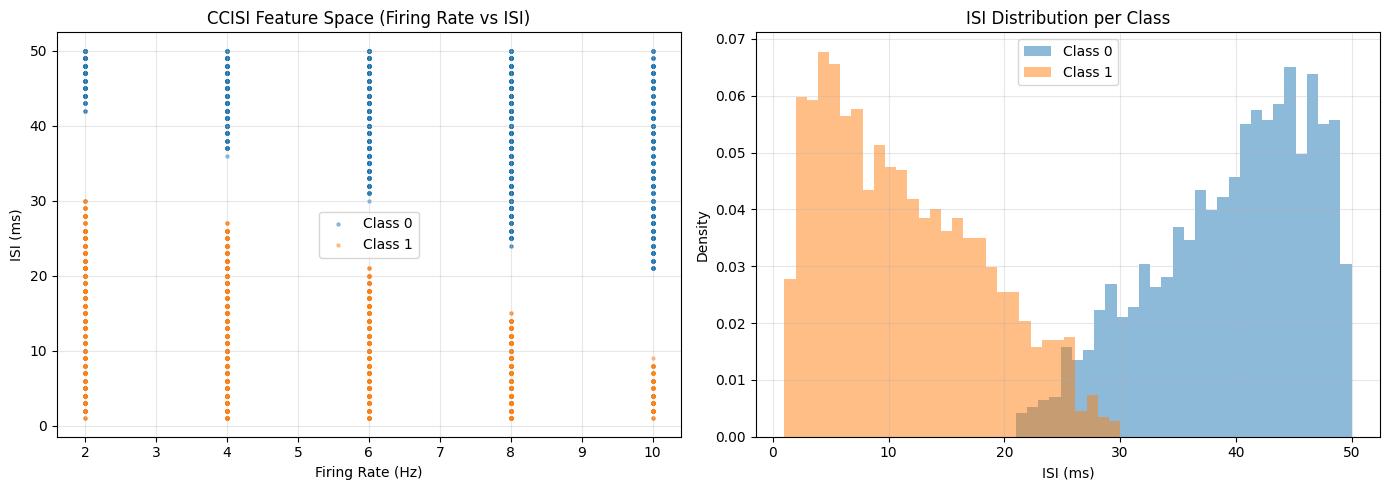

In [4]:
if firing_rates_all is not None and isis_all is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Feature space scatter: firing rate vs ISI, coloured by class
    for cls, color, label in zip([0, 1], ["tab:blue", "tab:orange"], ["Class 0", "Class 1"]):
        mask = Y_all == cls
        axes[0].scatter(
            firing_rates_all[mask], isis_all[mask],
            s=5, alpha=0.4, color=color, label=label,
        )
    axes[0].set_xlabel("Firing Rate (Hz)")
    axes[0].set_ylabel("ISI (ms)")
    axes[0].set_title("CCISI Feature Space (Firing Rate vs ISI)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ISI histogram per class to show temporal feature separation
    for cls, color, label in zip([0, 1], ["tab:blue", "tab:orange"], ["Class 0", "Class 1"]):
        mask = Y_all == cls
        axes[1].hist(isis_all[mask], bins=30, alpha=0.5, color=color, label=label, density=True)
    axes[1].set_xlabel("ISI (ms)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("ISI Distribution per Class")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. Hidden-Layer Spike Perturbation

The core perturbation mechanism from "Beyond Beyond Rate".
Given a hidden layer's binary spike output of shape `(neurons, T)`, we:
1. For each neuron, randomly select a fraction `f` of its spikes.
2. Remove them from their original positions.
3. Place the same number of spikes at uniformly random (previously-silent) time bins.

This destroys the temporal structure (including cross-channel ISI relationships
between hidden neurons) while **preserving each neuron's total spike count**.
Therefore, any accuracy drop under this perturbation reveals that the hidden
layer was encoding information temporally — not just in firing rates.

In [5]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref impl).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation (§3.6.5 Template A).

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly. All operations stay on the input tensor's device,
    avoiding the CPU/numpy round-trip that dominates training cost when
    perturbation runs on every batch (Section 7.1.3 of
    ``docs/progress/phase1to4_fixes.md``).

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5

    n_spikes = is_spike.sum(dim=-1, keepdim=True)
    num_to_move = (n_spikes.float() * f).floor().long()

    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move
    keep_mask = is_spike & ~remove_mask

    available = ~keep_mask
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move

    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype)
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A `Dataset` wrapper and helper to create train / validation / test DataLoaders.
Training always uses **unperturbed** data (f=0); perturbation is applied only
at test time inside the network's forward pass.

In [6]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple, total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 32,
) -> tuple:
    """Split data and return (train, val, test) DataLoaders.

    Data is NOT perturbed here — perturbation happens only at inference time
    inside forward_with_hidden_perturbation.

    Args:
        X: Spike-train array (N, num_neurons, T).
        Y: Label array (N,).
        batch_size: Mini-batch size.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    train_idx = get_split_indices(TRAIN_RANGE, len(X))
    val_idx   = get_split_indices(VAL_RANGE,   len(X))
    test_idx  = get_split_indices(TEST_RANGE,  len(X))

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds   = SpikeDataset(X[val_idx],   Y[val_idx])
    test_ds  = SpikeDataset(X[test_idx],  Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    print(f"Split sizes — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A single-hidden-layer SLAYER SNN with a **learnable PSP filter** AND
**learnable axonal delays** on both layers.

```
Input (20) → [delay1 + psp_filter + fc1 + spike] → Hidden (100)
                                                        ↓
                                ← perturbation hook (STE) applied here
                                                        ↓
                              [delay2 + psp + fc2 + spike] → Output (2)
```

The hidden-layer output of ``_first_layer`` is strictly binary (the spike
function is the last op), so the GPU-vectorised ``perturb_hidden_batch``
operates on the correct representation. ``forward(x, f)`` routes the
hidden spikes through ``_apply_perturbation`` — a straight-through
estimator that preserves gradient flow to ``fc1``, ``psp_filter`` and
``delay1``.

In [7]:
class CCISIDelayNetwork(nn.Module):
    """SLAYER SNN for CCISI classification with learnable tau AND axonal delays.

    ``delay1`` acts on the input side of ``_first_layer`` (per-input-neuron
    axonal delay); ``delay2`` sits at the start of ``_second_layer`` (after
    the perturbation hook). ``forward(x, f)`` applies the spike-relocation
    perturbation through a straight-through estimator so ``fc1`` /
    ``psp_filter`` / ``delay1`` still receive gradient when training at
    ``f > 0``.
    """

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
        max_delay: int = 10,
    ):
        super().__init__()
        self.max_delay = max_delay
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        # Two fully-connected SLAYER layers with weight normalisation
        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # Learnable PSP filter — replaces the fixed-tau PSP for the first layer.
        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        self._initialize_alpha_filter()

        # Learnable axonal delay modules on both layers.
        # delay1 on the input side; delay2 at the start of _second_layer (after the hook).
        self.delay1 = slayer.delay(num_neurons)
        self.delay2 = slayer.delay(hidden_units)
        self._initialize_delays()

    # ------------------------------------------------------------------
    # Initialisation helpers
    # ------------------------------------------------------------------

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau      = 50 * MS
        Ts       = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def _initialize_delays(self) -> None:
        """Initialize delay parameters uniformly in [0, max_delay]."""
        with torch.no_grad():
            if hasattr(self.delay1, "delay"):
                self.delay1.delay.data.uniform_(0, self.max_delay)
            if hasattr(self.delay2, "delay"):
                self.delay2.delay.data.uniform_(0, self.max_delay)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau (s) from the peak of the learned PSP filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx      = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def get_delays(self) -> dict:
        """Get current delay values as numpy arrays."""
        delays: dict = {}
        if hasattr(self.delay1, "delay"):
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
        if hasattr(self.delay2, "delay"):
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

    # ------------------------------------------------------------------
    # Internal layer helpers
    # ------------------------------------------------------------------

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D SLAYER format (N, C, 1, 1, T) on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> hidden spikes through delay1 + learnable PSP filter + fc1."""
        x = self.delay1(x)
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        """Hidden spikes -> output spikes through delay2 + standard PSP + fc2."""
        x = self.delay2(hidden_spikes)
        return self.slayer.spike(self.fc2(self.slayer.psp(x)))

    def _apply_perturbation(
        self,
        hidden: torch.Tensor,
        f: float,
    ) -> torch.Tensor:
        """STE wrapper around ``perturb_hidden_batch``.

        See Section 7.1 of ``docs/progress/phase1to4_fixes.md``. Without
        the STE, ``fc1`` / ``psp_filter`` / ``delay1`` would not receive
        gradient under ``f > 0``.
        """
        if f <= 0:
            return hidden
        perturbed = perturb_hidden_batch(hidden, f)
        return hidden + (perturbed - hidden).detach()

    # ------------------------------------------------------------------
    # Forward pass
    # ------------------------------------------------------------------

    def forward(self, x: torch.Tensor, f: float = 0.0) -> torch.Tensor:
        """Forward pass with optional hidden-layer perturbation at level *f*."""
        x = self._prepare_input(x)
        hidden = self._first_layer(x)
        hidden = self._apply_perturbation(hidden, f)
        return self._second_layer(hidden)

## 7. Training Loop

Train the `CCISIDelayNetwork` on **unperturbed** data (f=0). Key design choices:
- **SLAYER ProbSpikes loss**: surrogate-gradient loss for SNNs.
- **Nadam optimiser** with separate learning rates:
  - Regular parameters: base LR.
  - PSP filter (tau): LR × 10 for faster temporal adaptation.
  - Delay parameters: LR × 5 for stable delay learning.
- **MultiStepLR scheduler**: halves the LR at epoch 300.
- **Best-model checkpointing** based on validation loss.

In [8]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    max_delay: int = 10,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
    f: float = 0.0,
) -> tuple:
    """Train the CCISIDelayNetwork with perturbation level *f* active.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        num_neurons: Number of input neurons.
        num_classes: Number of output classes.
        hidden_units: Hidden layer size.
        max_delay: Maximum learnable delay in time steps.
        epochs: Number of training epochs.
        lr: Base learning rate.
        seed: Random seed; re-seeded inside so each f starts from the same init.
        f: Hidden-layer perturbation level applied during forward passes.

    Returns:
        Tuple of (trained CCISIDelayNetwork, training log dict).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = CCISIDelayNetwork(num_neurons, num_classes, hidden_units, max_delay).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron":     LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training":   {"error": {"type": "ProbSpikes"}},
    }).to(device)

    # Three parameter groups: regular, PSP filter (tau), delay
    psp_params   = list(net.psp_filter.parameters())
    delay_params = [p for name, p in net.named_parameters() if "delay" in name]

    psp_ids   = {id(p) for p in psp_params}
    delay_ids = {id(p) for p in delay_params}
    other_params = [
        p for p in net.parameters()
        if id(p) not in psp_ids and id(p) not in delay_ids
    ]

    optimizer = snn.utils.optim.Nadam([
        {"params": other_params, "lr": lr},
        {"params": psp_params,   "lr": lr * 10},
        {"params": delay_params, "lr": lr * 5},
    ])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.5
    )

    best_val_loss    = float("inf")
    best_model_state = None
    tau_history: list = []
    delay_history: list = []

    log: dict = {
        "epoch": [], "train_loss": [], "val_loss": [],
        "tau": [], "delay_mean": [], "f": f,
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Train f={f}") as pbar:
        for epoch in range(epochs):

            # --- Training phase ---
            net.train()
            epoch_loss  = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device)

                outputs     = net(x_batch, f=f)
                loss        = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss  += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            # --- Validation phase ---
            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device)

                    outputs   = net(x_batch, f=f)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss   /= len(val_loader)
            epoch_loss /= batch_count
            tau_val     = net.get_tau().item() / MS
            tau_history.append(tau_val)

            delays = net.get_delays()
            delay_history.append(delays)
            avg_delay = np.mean([
                np.mean(d) for d in delays.values() if len(d) > 0
            ])

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)
            log["delay_mean"].append(float(avg_delay))

            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
                delay=f"{avg_delay:.1f}",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate the trained model by sweeping over perturbation levels `f`.
For each `f`, we use `forward_with_hidden_perturbation` which intercepts
the first hidden layer's spike output before passing it to layer 2.

Each level is repeated `NUM_REPEATS` times with different random seeds to
obtain mean ± std accuracy estimates.

In [9]:
def test_with_hidden_perturbation(
    net: CCISIDelayNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*."""
    net.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs   = net(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total   += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: CCISIDelayNetwork,
    test_loader: DataLoader,
    f: float,
    num_repeats: int = 3,
) -> dict:
    """Repeat ``test_with_hidden_perturbation`` for mean ± std error bars."""
    accuracies: list = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        torch.manual_seed(SEED + repeat)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + repeat)
        accuracies.append(test_with_hidden_perturbation(net, test_loader, f=f))
    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": [float(a) for a in accuracies],
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training / validation loss curves, tau evolution, and delay evolution.
2. Accuracy vs hidden-perturbation level *f* (the main result plot).

In [10]:
def plot_training_curves(log: dict) -> None:
    """Plot training/validation loss, tau evolution, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    f_val = log.get("f", 0.0)

    # Loss curves
    axes[0].plot(log["epoch"], log["train_loss"], "o-", label="Train loss", markersize=2)
    axes[0].plot(log["epoch"], log["val_loss"],   "s-", label="Val loss", markersize=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("ProbSpikes Loss")
    axes[0].set_title(f"Training and Validation Loss (CCISI, f={f_val})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Tau evolution
    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Effective Tau (ms)")
    axes[1].set_title(f"Learned Tau Evolution (CCISI, f={f_val})")
    axes[1].grid(True, alpha=0.3)

    # Delay evolution
    axes[2].plot(log["delay_mean"])
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Average Delay (time steps)")
    axes[2].set_title(f"Average Delay Evolution (CCISI, f={f_val})")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(
    results: dict,
    save_path: Optional[str] = None,
) -> None:
    """Plot accuracy vs hidden-perturbation level f (train-at-f / eval-at-f)."""
    f_vals = sorted(results.keys())
    means  = [results[f]["mean"] for f in f_vals]
    stds   = [results[f]["std"]  for f in f_vals]
    chance = 1.0 / NUM_CLASSES

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        f_vals, means, yerr=stds,
        fmt="o-", capsize=5, capthick=2,
        color="tab:orange", label="SGD-delay (learnable tau + delay)",
    )
    plt.axhline(
        chance, color="gray", linestyle="--", linewidth=1,
        label=f"Chance level ({chance:.2f})",
    )
    plt.xlabel("Hidden Perturbation Level (f) — trained & evaluated at this f")
    plt.ylabel("Test Accuracy")
    plt.title(
        "Exp 1B — CCISI: Train-at-f / Eval-at-f (Learnable Tau + Delay)"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean in zip(f_vals, means):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    plt.show()

## 10. Run: Train-at-f / Eval-at-f Sweep

For each *f* in ``F_VALUES`` we instantiate a fresh model from ``SEED``,
train with that perturbation level active on every batch, save the
checkpoint with *f* baked into the filename, then evaluate at the same *f*
with ``NUM_REPEATS`` repeats.

In [11]:
# Build DataLoaders. Perturbation is applied inside the forward pass.
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE,
)

os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

all_models: dict = {}
all_logs: dict = {}
sweep_results: dict = {}

for f_val in F_VALUES:
    print(f"\n=== Training at f={f_val} ===")
    net, training_log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        num_neurons=NUM_NEURONS,
        num_classes=NUM_CLASSES,
        hidden_units=HIDDEN_UNITS,
        max_delay=MAX_DELAY,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        seed=SEED,
        f=f_val,
    )

    model_path = f"data/{MODEL_PREFIX}_f{f_val}.pt"
    torch.save(net.state_dict(), model_path)

    result = test_with_repeats(net, test_loader, f=f_val, num_repeats=NUM_REPEATS)
    all_models[f_val] = net
    all_logs[f_val] = training_log
    sweep_results[f_val] = result
    print(
        f"f={f_val} | test acc = {result['mean']:.4f} ± {result['std']:.4f}"
        f" | checkpoint -> {model_path}"
    )

Split sizes — Train: 2158, Val: 540, Test: 540

=== Training at f=0.0 ===


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Train f=0.0:   0%|          | 0/20468 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Train f=0.0: 100%|██████████| 20468/20468 [07:42<00:00, 44.26it/s, best=0.0815, delay=6.0, epoch=301, tau=87.0ms, val_loss=0.1722]
d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is d

f=0.0 | test acc = 0.9944 ± 0.0000 | checkpoint -> data/ccisi_delay_f0.0.pt

=== Training at f=0.2 ===


Train f=0.2: 100%|██████████| 20468/20468 [12:56<00:00, 26.35it/s, best=0.1317, delay=5.4, epoch=301, tau=87.0ms, val_loss=0.2067]


f=0.2 | test acc = 0.9765 ± 0.0035 | checkpoint -> data/ccisi_delay_f0.2.pt

=== Training at f=0.4 ===


...

f=0.6 | test acc = 0.9840 ± 0.0009 | checkpoint -> data/ccisi_delay_f0.6.pt

=== Training at f=0.8 ===


Train f=0.8: 100%|██████████| 20468/20468 [12:53<00:00, 26.45it/s, best=0.2037, delay=4.9, epoch=301, tau=78.0ms, val_loss=0.2066]


f=0.8 | test acc = 0.9778 ± 0.0015 | checkpoint -> data/ccisi_delay_f0.8.pt

=== Training at f=1.0 ===


Train f=1.0: 100%|██████████| 20468/20468 [12:54<00:00, 26.42it/s, best=0.1712, delay=4.9, epoch=301, tau=84.0ms, val_loss=0.1770]


f=1.0 | test acc = 0.9827 ± 0.0009 | checkpoint -> data/ccisi_delay_f1.0.pt


## 10b. Diagnostic — STE Health Check

Per §3.6 / §5 of `docs/progress/phase1to4_fixes.md`. If two `f > 0` rows
show bit-identical `fc1.norm`, the STE regressed (Issue 1).
`hidden_unique` should be `[0.0, 1.0]`.

In [12]:
print(f"{'f':>6}  {'fc1.norm':>10}  {'psp.norm':>10}  {'d1.mean':>8}  {'d2.mean':>8}  hidden_unique")
for f_val, mdl in all_models.items():
    fc1_norm = sum(
        p.norm().item()
        for name, p in mdl.named_parameters()
        if name.startswith("fc1.weight")
    )
    psp_norm = mdl.psp_filter.weight.norm().item()
    delays = mdl.get_delays()
    d1_mean = float(np.mean(delays.get("delay1", [0.0])))
    d2_mean = float(np.mean(delays.get("delay2", [0.0])))
    with torch.no_grad():
        x_b, _ = next(iter(test_loader))
        if x_b.dim() == 3:
            x_b = x_b.unsqueeze(2).unsqueeze(3)
        x_b = x_b.to(device).float()
        hidden = mdl._first_layer(x_b)
        unique = torch.unique(hidden).cpu().tolist()
    print(
        f"{f_val:>6.2f}  {fc1_norm:>10.4f}  {psp_norm:>10.4f}  "
        f"{d1_mean:>8.3f}  {d2_mean:>8.3f}  {unique}"
    )

     f    fc1.norm    psp.norm   d1.mean   d2.mean  hidden_unique
  0.00    115.5316     10.6405     4.602     7.317  [0.0, 1.0]
  0.20    115.5264     12.4014     4.793     5.975  [0.0, 1.0]
  0.40    115.5366     11.5943     4.647     5.486  [0.0, 1.0]
  0.60    115.4626      9.4934     4.483     5.245  [0.0, 1.0]
  0.80    115.5381     10.1545     4.450     5.355  [0.0, 1.0]
  1.00    115.5242      9.8510     4.419     5.305  [0.0, 1.0]


## 11. Plot Training Curves (per f)

Plot loss, tau evolution and delay evolution for each trained model.


--- Training curves at f=0.0 ---


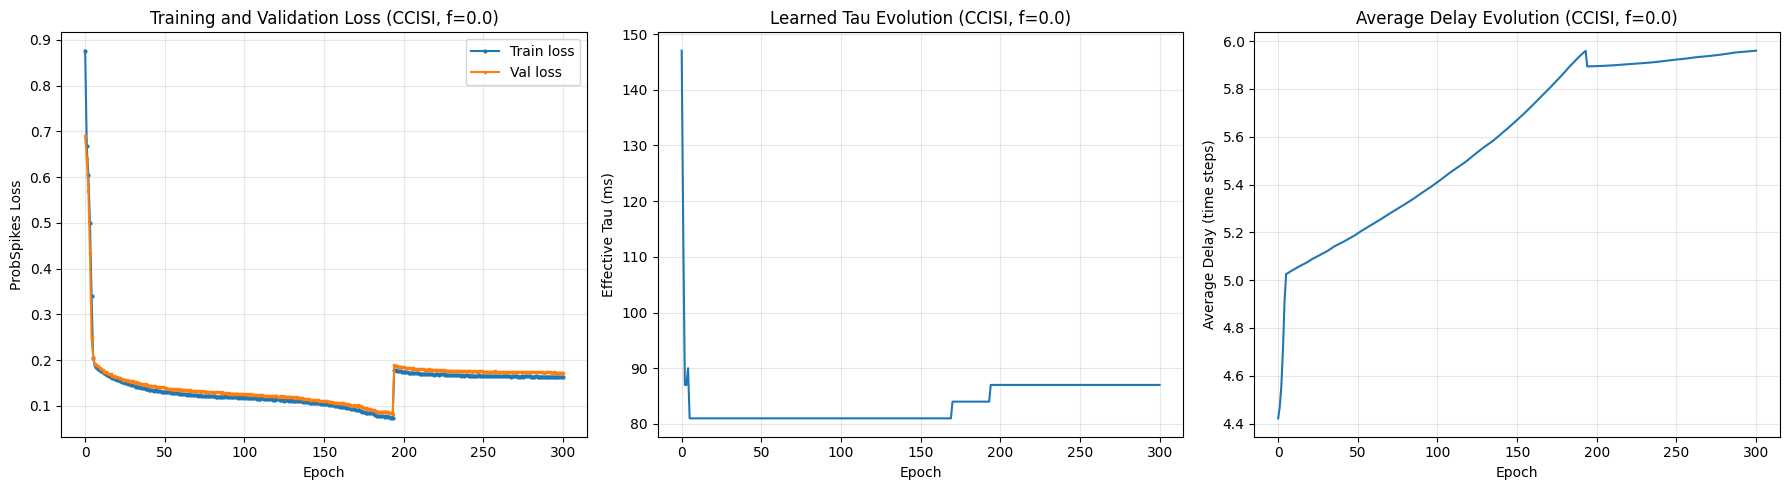


--- Training curves at f=0.2 ---


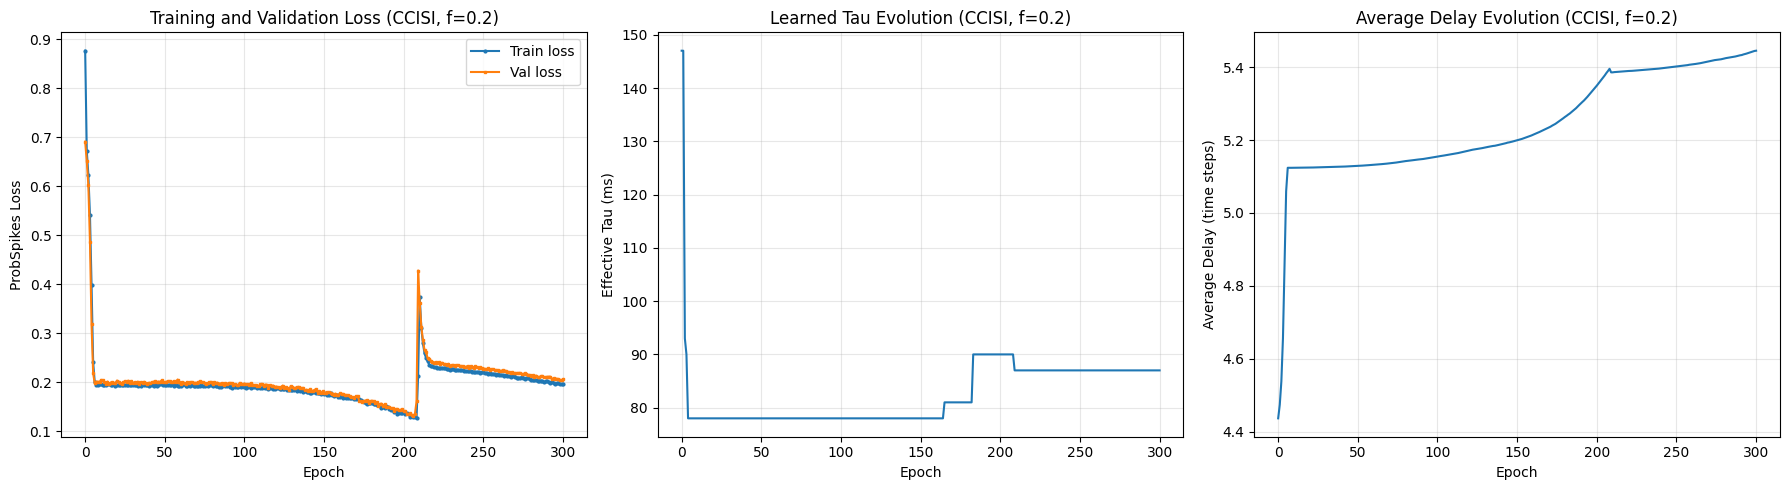


--- Training curves at f=0.4 ---


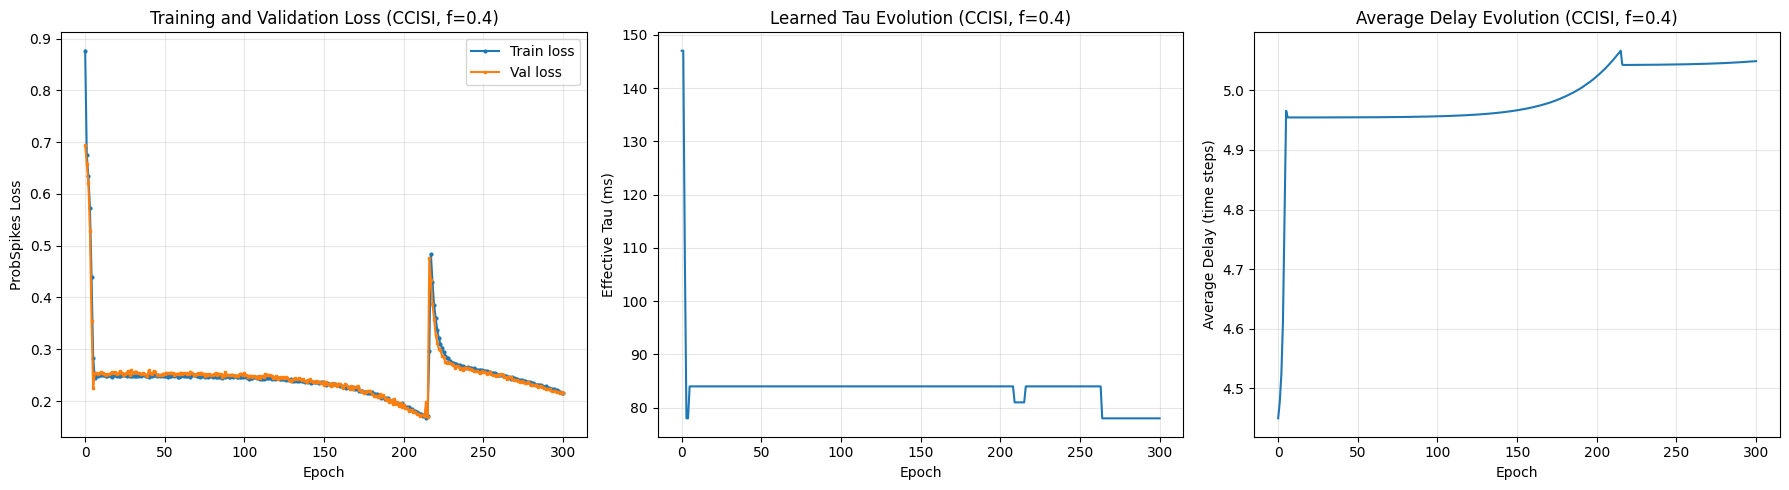


--- Training curves at f=0.6 ---


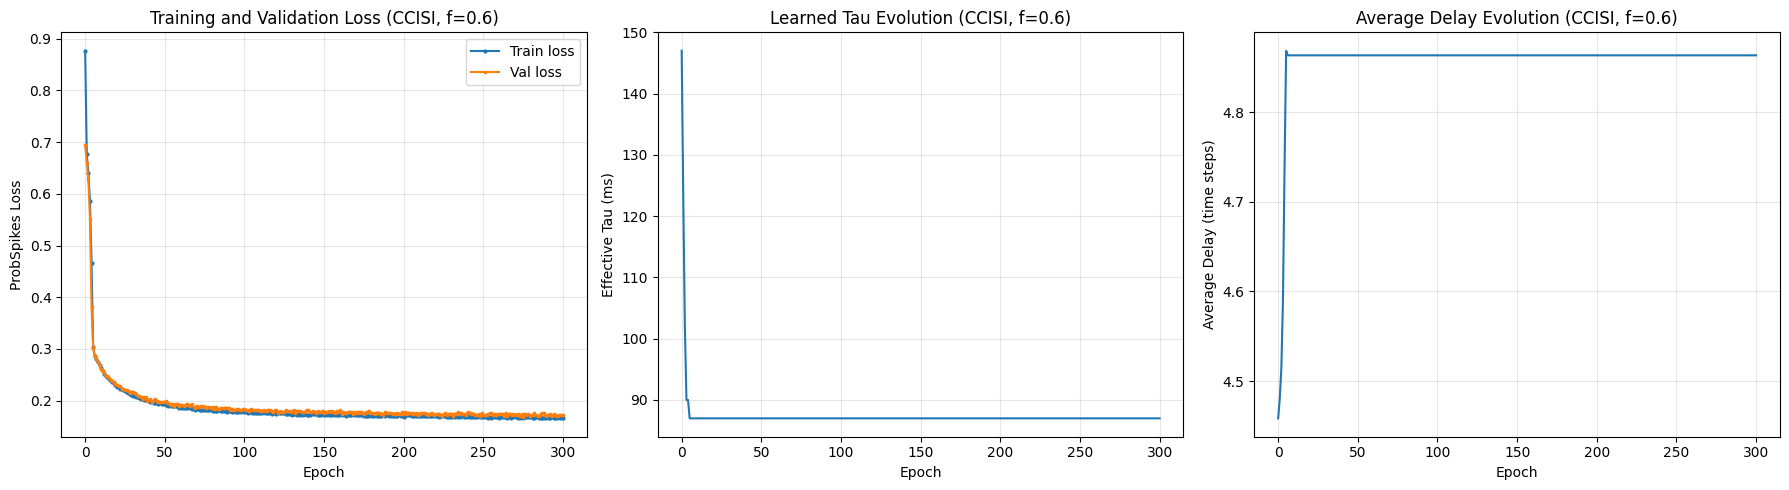


--- Training curves at f=0.8 ---


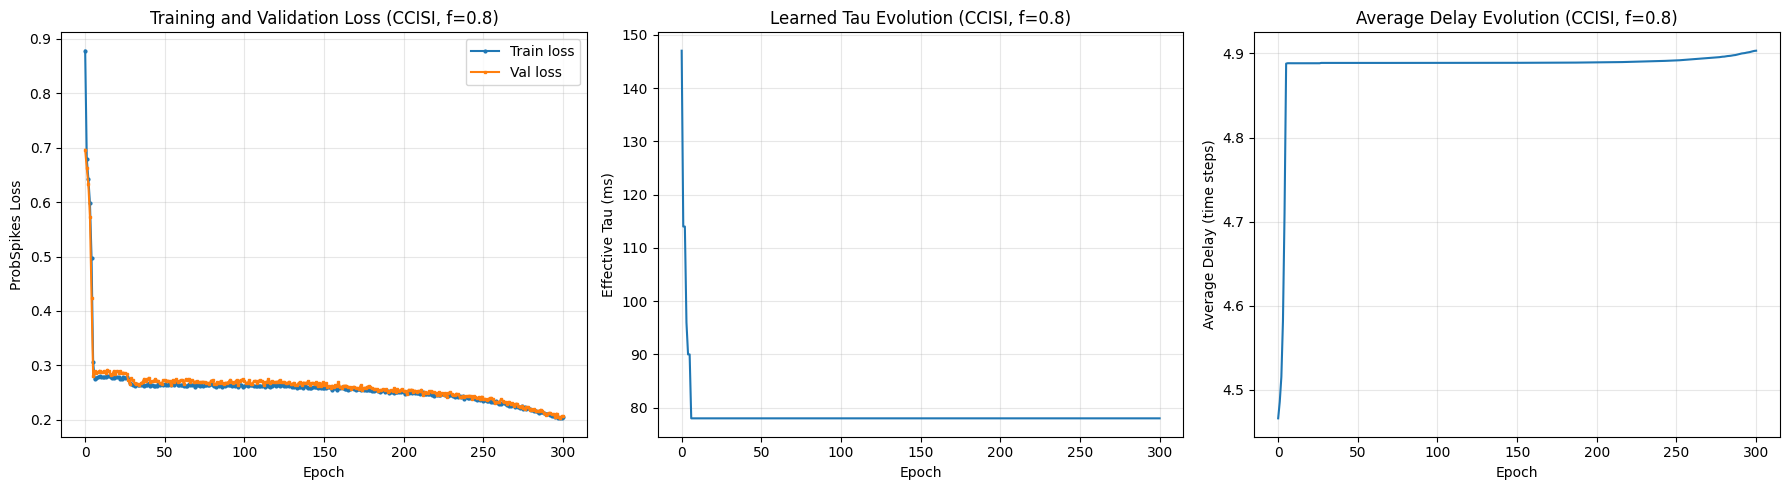


--- Training curves at f=1.0 ---


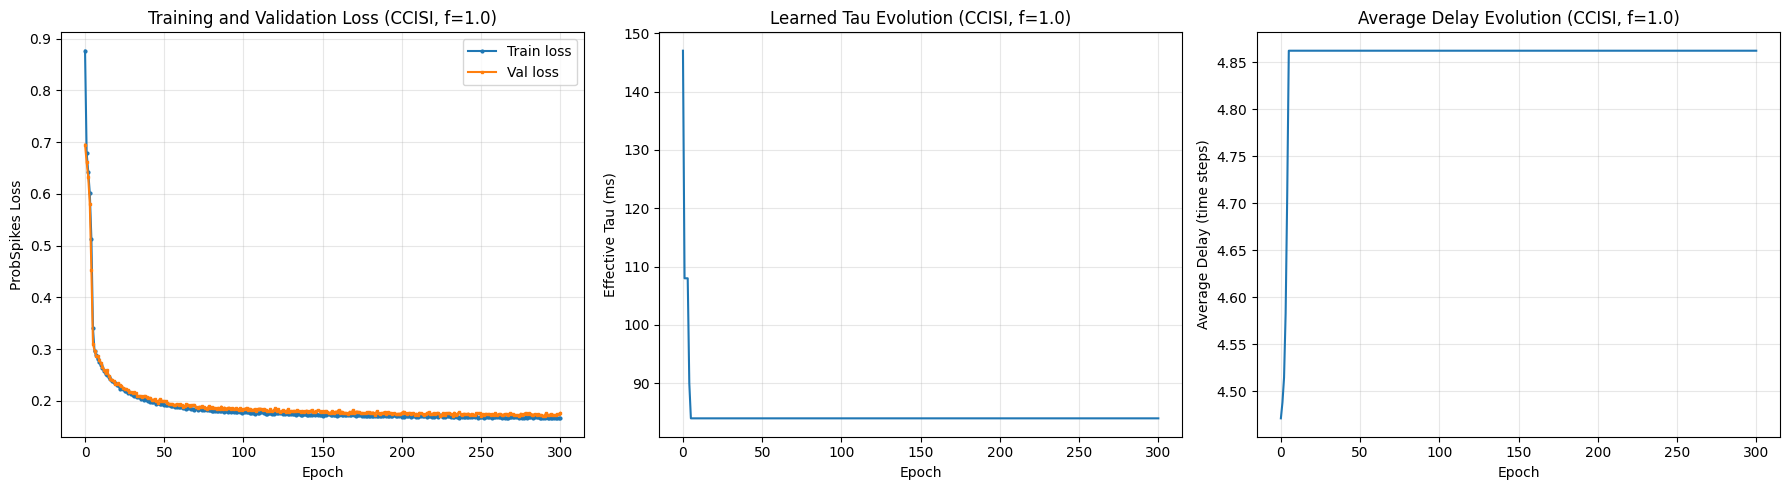

In [13]:
for f_val in F_VALUES:
    print(f"\n--- Training curves at f={f_val} ---")
    plot_training_curves(all_logs[f_val])

## 12. Sweep Summary

The sweep was already executed in §10 — one model trained per *f* and
evaluated at the same *f*. Print collected accuracies for inspection.

In [14]:
print("=== Train-at-f / Eval-at-f Sweep Summary (CCISI, learnable tau + delay) ===")
for f_val in sorted(sweep_results.keys()):
    data = sweep_results[f_val]
    print(f"  f={f_val:.1f}:  accuracy = {data['mean']:.4f} +/- {data['std']:.4f}")

=== Train-at-f / Eval-at-f Sweep Summary (CCISI, learnable tau + delay) ===
  f=0.0:  accuracy = 0.9944 +/- 0.0000
  f=0.2:  accuracy = 0.9765 +/- 0.0035
  f=0.4:  accuracy = 0.9673 +/- 0.0038
  f=0.6:  accuracy = 0.9840 +/- 0.0009
  f=0.8:  accuracy = 0.9778 +/- 0.0015
  f=1.0:  accuracy = 0.9827 +/- 0.0009


## 13. Plot Hidden-Perturbation Results

Figure saved to log/ccisi_delay_hidden_perturbation.png


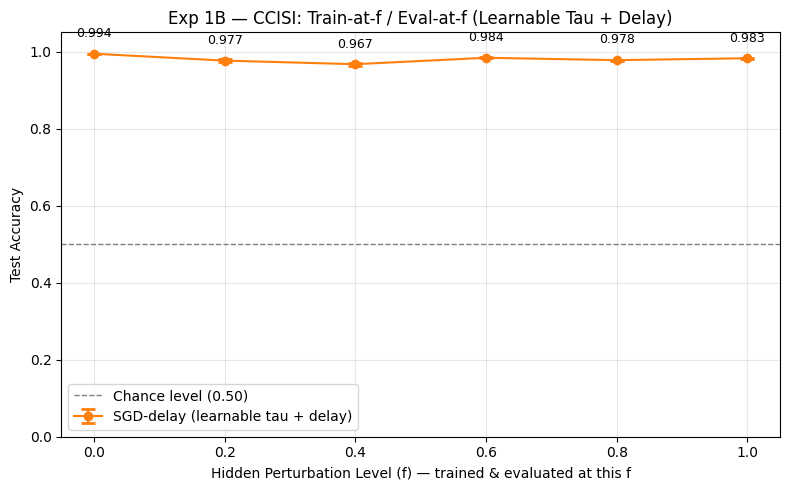

In [15]:
plot_hidden_perturbation_curve(
    sweep_results,
    save_path="log/ccisi_delay_hidden_perturbation.png",
)

## 14. Save Results

Save the perturbation sweep results and training log to JSON for:
- Later side-by-side comparison with `ccisi_tau.ipynb` (SGD tau-only model).
- Comparison against the original input-perturbation baseline from Beyond Rate.

In [16]:
# Save perturbation sweep results
results_serialisable = {
    str(f_val): {
        "mean":   float(data["mean"]),
        "std":    float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

results_path = f"log/{MODEL_PREFIX}_hidden_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Perturbation results saved to {results_path}")

# Save per-f training logs
training_logs_serialisable = {
    str(f_val): {
        k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
        for k, vals in log.items()
    }
    for f_val, log in all_logs.items()
}
log_path = f"log/{MODEL_PREFIX}_training_log.json"
with open(log_path, "w") as fp:
    json.dump(training_logs_serialisable, fp, indent=2)
print(f"Training logs saved to {log_path}")

Perturbation results saved to log/ccisi_delay_hidden_perturbation_results.json
Training logs saved to log/ccisi_delay_training_log.json


## 15. Model Analysis

Inspect the learned tau, delay distributions, and PSP filter shape to understand
what temporal scale and axonal delays the network adapted to for the CCISI task.

=== Learned Parameter Analysis (CCISI, learnable tau + delay) ===

     f    tau (ms)    d1 mean     d1 std    d2 mean     d2 std
   0.0       84.00      4.602      2.630      7.317      9.678
   0.2       90.00      4.793      2.635      5.975      3.502
   0.4       81.00      4.647      2.537      5.486      3.057
   0.6       87.00      4.483      2.523      5.245      3.004
   0.8       78.00      4.450      2.512      5.355      3.032
   1.0       84.00      4.419      2.512      5.305      3.007


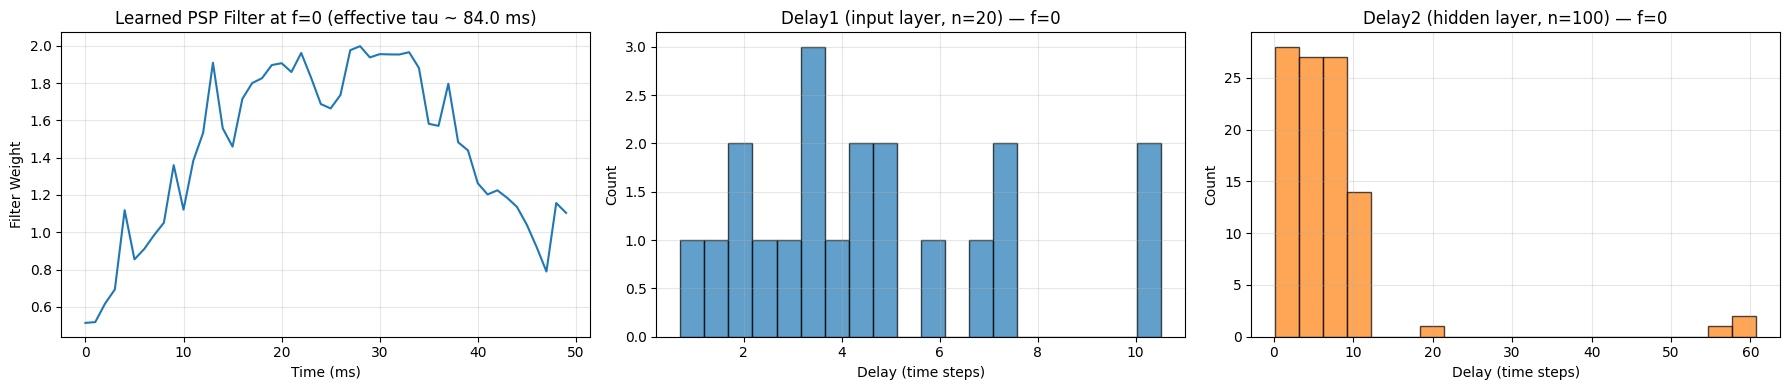


Weight statistics (f=0 baseline):
  fc1.weight_g: mean=5.7668, std=0.6551, shape=[100, 1, 1, 1, 1]
  fc1.weight_v: mean=-0.0054, std=1.2860, shape=[100, 20, 1, 1, 1]
  fc2.weight_g: mean=10.0280, std=6.9164, shape=[2, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.1098, std=0.5791, shape=[2, 100, 1, 1, 1]
  psp_filter.weight: mean=1.4397, std=0.4421, shape=[1, 1, 1, 1, 50]


In [17]:
print("=== Learned Parameter Analysis (CCISI, learnable tau + delay) ===\n")

print(f"{'f':>6}  {'tau (ms)':>10}  {'d1 mean':>9}  {'d1 std':>9}  {'d2 mean':>9}  {'d2 std':>9}")
for f_val, mdl in all_models.items():
    tau_v = mdl.get_tau().item() / MS
    d = mdl.get_delays()
    d1 = d.get("delay1")
    d2 = d.get("delay2")
    d1m = float(np.mean(d1)) if d1 is not None and len(d1) > 0 else float("nan")
    d1s = float(np.std(d1)) if d1 is not None and len(d1) > 0 else float("nan")
    d2m = float(np.mean(d2)) if d2 is not None and len(d2) > 0 else float("nan")
    d2s = float(np.std(d2)) if d2 is not None and len(d2) > 0 else float("nan")
    print(f"{f_val:>6.1f}  {tau_v:>10.2f}  {d1m:>9.3f}  {d1s:>9.3f}  {d2m:>9.3f}  {d2s:>9.3f}")

# Detailed plots for the f=0 baseline model
baseline = all_models[0.0]
tau_val = baseline.get_tau().item() / MS
filter_weights = baseline.psp_filter.weight.data.squeeze().cpu().numpy()
delays = baseline.get_delays()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.flip(filter_weights))
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Filter Weight")
axes[0].set_title(f"Learned PSP Filter at f=0 (effective tau ~ {tau_val:.1f} ms)")
axes[0].grid(True, alpha=0.3)

if "delay1" in delays and len(delays["delay1"]) > 0:
    axes[1].hist(
        delays["delay1"].flatten(), bins=20,
        color="tab:blue", alpha=0.7, edgecolor="black",
    )
    axes[1].set_xlabel("Delay (time steps)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Delay1 (input layer, n={delays['delay1'].size}) — f=0")
    axes[1].grid(True, alpha=0.3)

if "delay2" in delays and len(delays["delay2"]) > 0:
    axes[2].hist(
        delays["delay2"].flatten(), bins=20,
        color="tab:orange", alpha=0.7, edgecolor="black",
    )
    axes[2].set_xlabel("Delay (time steps)")
    axes[2].set_ylabel("Count")
    axes[2].set_title(f"Delay2 (hidden layer, n={delays['delay2'].size}) — f=0")
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Weight statistics for the f=0 baseline model
print("\nWeight statistics (f=0 baseline):")
for name, param in baseline.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"  {name}: mean={w.mean().item():.4f}, std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )

## 16. Summary and Interpretation

Print a concise summary of the experiment results and interpret the
accuracy-vs-f curve in the context of the CCISI temporal coding question.

In [18]:
print("=" * 62)
print("EXPERIMENT 1B SUMMARY: CCISI Train-at-f / Eval-at-f")
print("Model: SGD-delay with learnable tau + learnable delays")
print("=" * 62)
print(f"{'f':>6}  {'Accuracy':>10}  {'Std':>8}")
print("-" * 30)
for f_val in sorted(sweep_results.keys()):
    data = sweep_results[f_val]
    print(f"{f_val:>6.1f}  {data['mean']:>10.4f}  {data['std']:>8.4f}")

# Accuracy drop from clean to fully-perturbed
acc_f0 = sweep_results[0.0]["mean"]
acc_f1 = sweep_results[1.0]["mean"]
drop   = acc_f0 - acc_f1
print(f"\nAccuracy drop (f=0 to f=1): {drop:.4f}")

if drop > 0.05:
    print("-> The hidden layer PRESERVES temporal structure.")
    print("   Cross-channel ISI information is maintained as a timing code.")
else:
    print("-> The hidden layer COLLAPSES temporal structure.")
    print("   Cross-channel ISI information has been converted to a rate code.")

# Delay summary for the f=0 baseline
baseline = all_models[0.0]
for delay_name, delay_values in baseline.get_delays().items():
    if len(delay_values) > 0:
        print(
            f"\nf=0 baseline {delay_name}: mean={np.mean(delay_values):.2f}, "
            f"std={np.std(delay_values):.2f}"
        )

print(f"\nOutput files in: log/")
print("Next step: compare with ccisi_tau.ipynb results (SGD tau-only model).")

EXPERIMENT 1B SUMMARY: CCISI Train-at-f / Eval-at-f
Model: SGD-delay with learnable tau + learnable delays
     f    Accuracy       Std
------------------------------
   0.0      0.9944    0.0000
   0.2      0.9765    0.0035
   0.4      0.9673    0.0038
   0.6      0.9840    0.0009
   0.8      0.9778    0.0015
   1.0      0.9827    0.0009

Accuracy drop (f=0 to f=1): 0.0117
-> The hidden layer COLLAPSES temporal structure.
   Cross-channel ISI information has been converted to a rate code.

f=0 baseline delay1: mean=4.60, std=2.63

f=0 baseline delay2: mean=7.32, std=9.68

Output files in: log/
Next step: compare with ccisi_tau.ipynb results (SGD tau-only model).
